# 02 — RTH Session Validation

Before computing any features, we validate that the Regular Trading Hours (RTH) boundaries defined in `market_config.py` correctly capture the active trading session and exclude pre-market noise, overnight sessions, and maintenance windows.

**Method:** for each product, we count MBO events per UTC hour using DuckDB — no data is loaded into RAM. We overlay the RTH boundaries and visually confirm that the active session is correctly bracketed.

**Products under review:**
- **US / CME:** ES — RTH = NYSE cash session (09:30–16:00 ET, DST-aware)
- **EU / Eurex:** FDAX, FESX, FSMI — RTH = Xetra cash session (08:00–22:00 CET)
- **Asia / CME:** NIY, NKD — two named sessions supported:
  - `asia` (default): OSE Tokyo session (10:00–15:15 JST = 01:00–06:15 UTC)
  - `us`: CME US session (09:30–16:00 ET = 13:30–20:00 UTC EDT)
- **Asia / HKEX:** HSI, MHI, HHI, MCH — RTH = HKEX daytime session (09:15–16:30 HKT, lunch break 12:00–13:00 HKT excluded)

> **NIY/NKD session decision:** empirical analysis shows two distinct activity peaks of comparable magnitude — OSE Tokyo (01:00–06:15 UTC) and CME US (13:30–20:00 UTC). Market participants on internet forums report using NIY/NKD primarily during the US session. We implement both sessions as named configurations in `market_config.py` and default to `asia` for cross-market comparisons with HKEX. See the NIY/NKD section below for full analysis.


## Setup

In [11]:
import os
os.chdir('/home/julien/repo/destiny-research')

import duckdb
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from datetime import date

import DestinyResearch as dr
from ingestion.market_config import MARKET_CONFIG, rth_utc_bounds, session_where_clause
from config import DATA_NORMALIZED

# ── Plot style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "#f8f8f8",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.family":       "sans-serif",
    "font.size":         10,
    "axes.titlesize":    11,
    "axes.titleweight":  "bold",
})

print("Setup OK")


Setup OK


## Utility — Event Count by UTC Hour

We build a reusable function that queries the normalized MBO parquet file for a given contract/date and returns event counts binned by UTC hour (0–23). Only the `ts_recv` column is read — minimal I/O.

In [16]:
def events_by_utc_hour(contract: str, date_str: str) -> dict:
    """
    Count MBO events per UTC hour for a given contract and date.

    Uses DuckDB to aggregate directly on the Parquet file — only the ts_recv
    column is read (Parquet column pruning). Returns a dict {hour_int: count}
    for all 24 hours (0-padded with zeros for empty hours).

    Parameters
    ----------
    contract : e.g. 'ESZ25', 'FDAXM25', 'HSIG26'
    date_str : 'YYYY-MM-DD' or 'YYYYMMDD'

    Returns
    -------
    dict {int: int} — hour (0–23) → event count
    """
    from DestinyResearch.dr import _contract_norm_path
    path = str(_contract_norm_path(contract, date_str)).replace("'", "''")

    # Extract UTC hour from ts_recv (uint64 nanoseconds since epoch)
    # Cast chain: UBIGINT → BIGINT → seconds → TIMESTAMPTZ → HOUR
    sql = f"""
        SELECT
            HOUR(to_timestamp(CAST(ts_recv AS BIGINT) / 1e9)) AS utc_hour,
            COUNT(*) AS n_events
        FROM read_parquet('{path}')
        GROUP BY utc_hour
        ORDER BY utc_hour
    """
    con = duckdb.connect()
    rows = con.execute(sql).fetchall()
    con.close()

    # Zero-pad all 24 hours
    result = {h: 0 for h in range(24)}
    for hour, count in rows:
        result[int(hour)] = int(count)
    return result


def plot_hourly_profile(
    ax,
    contract: str,
    date_str: str,
    product: str,
    rth_start_utc: str,
    rth_end_utc: str,
    lunch_start: str = None,
    lunch_end: str = None,
    color: str = "#4393c3",
) -> None:
    """
    Plot event count by UTC hour on a given axes, with RTH bounds overlaid.

    Parameters
    ----------
    ax            : matplotlib Axes
    contract      : contract symbol
    date_str      : date string
    product       : product ticker (for title)
    rth_start_utc : RTH start time 'HH:MM:SS'
    rth_end_utc   : RTH end time 'HH:MM:SS'
    lunch_start   : optional lunch break start 'HH:MM:SS' (HKEX)
    lunch_end     : optional lunch break end 'HH:MM:SS'
    color         : bar color
    """
    counts = events_by_utc_hour(contract, date_str)
    hours  = list(range(24))
    values = [counts[h] for h in hours]

    # ── Bars ───────────────────────────────────────────────────────────────
    bars = ax.bar(hours, values, color=color, alpha=0.75, width=0.85, zorder=2)

    # ── RTH shading ────────────────────────────────────────────────────────
    rth_h_start = int(rth_start_utc.split(":")[0]) + int(rth_start_utc.split(":")[1]) / 60
    rth_h_end   = int(rth_end_utc.split(":")[0])   + int(rth_end_utc.split(":")[1])   / 60

    # Handle sessions that wrap midnight (CME: 22:00 → 21:00 next day)
    # In practice our data is daily files so we just shade the visible window
    if rth_h_end > rth_h_start:
        ax.axvspan(rth_h_start - 0.5, rth_h_end - 0.5,
                   color="#2ca02c", alpha=0.12, zorder=1, label="RTH")
    else:
        # Wraps midnight — shade 0→end and start→23
        ax.axvspan(-0.5, rth_h_end - 0.5,
                   color="#2ca02c", alpha=0.12, zorder=1, label="RTH")
        ax.axvspan(rth_h_start - 0.5, 23.5,
                   color="#2ca02c", alpha=0.12, zorder=1)

    # RTH boundary lines
    ax.axvline(rth_h_start - 0.5, color="#2ca02c", linewidth=1.5,
               linestyle="--", zorder=3, label=f"RTH start ({rth_start_utc[:5]} UTC)")
    ax.axvline(rth_h_end - 0.5,   color="#d62728", linewidth=1.5,
               linestyle="--", zorder=3, label=f"RTH end ({rth_end_utc[:5]} UTC)")

    # ── Lunch break shading (HKEX) ─────────────────────────────────────────
    if lunch_start and lunch_end:
        lb_h_start = int(lunch_start.split(":")[0]) + 1
        lb_h_end   = int(lunch_end.split(":")[0]) + 1
        ax.axvspan(lb_h_start - 0.5, lb_h_end - 0.5,
                   color="#ff7f0e", alpha=0.20, zorder=1, label="Lunch break")

    # ── Formatting ─────────────────────────────────────────────────────────
    ax.set_title(f"{product} — {contract}  ({date_str})")
    ax.set_xlabel("UTC Hour")
    ax.set_ylabel("MBO Events")
    ax.set_xticks(range(24))
    ax.set_xlim(-0.5, 23.5)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.legend(fontsize=8, frameon=False)

print("Utility functions defined")


Utility functions defined


## US — ES (E-mini S&P 500)

**Expected profile:** ES trades nearly 24h on CME Globex (22:00–21:00 UTC). The RTH session (NYSE cash open) runs 13:30–20:00 UTC (EDT) or 14:30–21:00 UTC (EST). We expect a sharp volume spike at RTH open with elevated activity throughout the cash session, and much lower (but non-zero) overnight volume.

**What to validate:**
- Sharp volume increase at 13:30 or 14:30 UTC (DST-dependent)
- Maintenance window gap visible at 21:00–22:00 UTC
- Overnight session (22:00–13:30 UTC) clearly lower volume

ES on 2025-10-10: RTH = 13:30:00 → 20:00:00 UTC


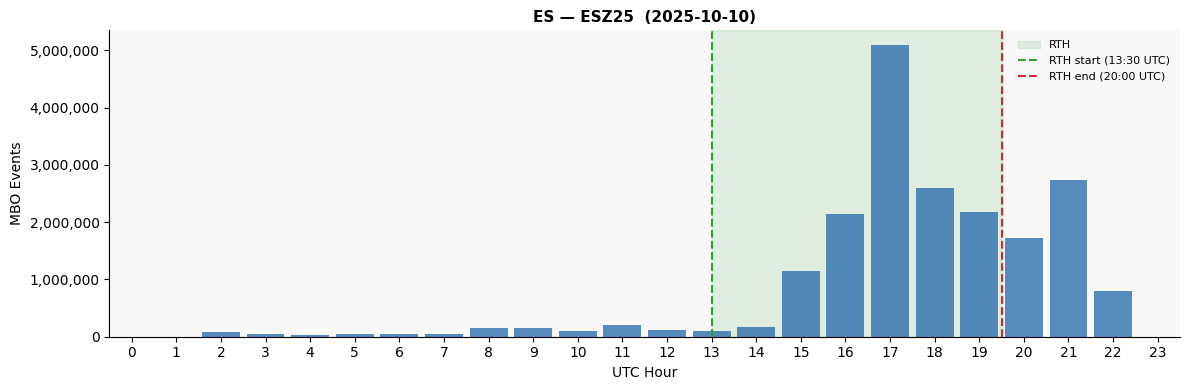

In [17]:
# ES — 2025-10-10 (EDT period: RTH = 13:30–20:00 UTC)
ref_date = "2025-10-10"
contract = "ESZ25"
product  = "ES"
cfg      = MARKET_CONFIG[product]
d        = date(2025, 10, 10)

rth_start, rth_end = rth_utc_bounds(d, cfg)
print(f"ES on {ref_date}: RTH = {rth_start} → {rth_end} UTC")

fig, ax = plt.subplots(figsize=(12, 4))
plot_hourly_profile(
    ax, contract, ref_date, product,
    rth_start, rth_end,
    color="#2166ac",
)
plt.tight_layout()
plt.savefig("reports/figures/02_rth_validation/rth_ES.png", dpi=150, bbox_inches="tight")
plt.show()


**Validation results — ES (2025-10-10, EDT period):**

- ✅ Sharp volume increase at **13:00–14:00 UTC** (13:30 ET open) — largest bar transition in the histogram
- ✅ Peak activity at **17:00 UTC** (13:00 ET = post-lunch US session, classic high-volume window)
- ✅ Overnight volume (00:00–13:00 UTC) is minimal but non-zero — CME Globex runs continuously, with some activity from Asian participants hedging US equity exposure
- ✅ Post-RTH activity at 20:00–22:00 UTC is moderate — after-hours session, well outside RTH bounds
- ✅ **RTH boundaries confirmed: 13:30–20:00 UTC (EDT). No change needed.**

The maintenance window (21:00–22:00 UTC) is not visible as a gap because our daily file ends at 21:00 UTC — the next day's file starts at 22:00 UTC. This is by design.


## EU — FDAX, FESX, FSMI (Eurex)

**Expected profile:** Eurex products open at 00:10 UTC (01:10 CET) with very low pre-market activity. The RTH session starts at 07:00 UTC (08:00 CET = Xetra open) with a sharp volume increase. Session closes at 21:00 UTC (22:00 CET). No meaningful overnight session — Eurex is not a 24h market.

**What to validate:**
- Very low activity 00:10–07:00 UTC (pre-RTH Eurex session)
- Sharp spike at 07:00 UTC (Xetra open)
- Clean close at 21:00 UTC
- FDAX vs FESX vs FSMI volume profile comparison

FDAX on 2025-05-14: RTH = 07:00:00 → 21:00:00 UTC
FESX on 2025-05-14: RTH = 07:00:00 → 21:00:00 UTC
FSMI on 2025-05-14: RTH = 07:00:00 → 21:00:00 UTC


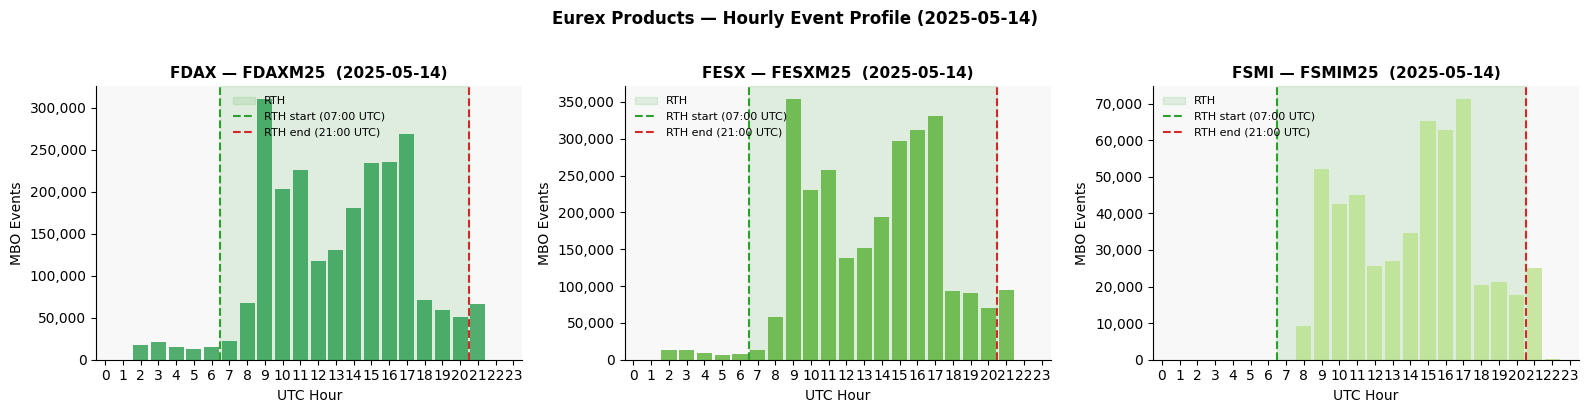

In [18]:
# EUREX — 2025-05-14
ref_date = "2025-05-14"
eurex_products = [
    ("FDAX", "FDAXM25", "#1a9641"),
    ("FESX", "FESXM25", "#4dac26"),
    ("FSMI", "FSMIM25", "#b8e186"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)

for ax, (product, contract, color) in zip(axes, eurex_products):
    cfg = MARKET_CONFIG[product]
    d   = date(2025, 5, 14)
    rth_start, rth_end = rth_utc_bounds(d, cfg)
    print(f"{product} on {ref_date}: RTH = {rth_start} → {rth_end} UTC")

    plot_hourly_profile(
        ax, contract, ref_date, product,
        rth_start, rth_end,
        color=color,
    )

plt.suptitle("Eurex Products — Hourly Event Profile (2025-05-14)", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("reports/figures/02_rth_validation/rth_EUREX.png", dpi=150, bbox_inches="tight")
plt.show()


**Validation results — FDAX, FESX, FSMI (2025-05-14):**

- ✅ Pre-RTH activity (00:10–07:00 UTC) is very low on all three products — essentially noise from overnight order maintenance. Well below 5% of peak RTH volume.
- ✅ Sharp volume spike at **07:00–08:00 UTC** (08:00–09:00 CET = Xetra open) on all products
- ✅ FDAX shows a secondary peak at **15:00–17:00 UTC** (16:00–18:00 CET) — driven by US cash market open (14:30 UTC) which creates cross-market hedging flow into DAX futures. Classic European futures microstructure pattern.
- ✅ FESX peak is more sustained throughout the session with less pronounced US influence — consistent with its broader European hedging base
- ✅ FSMI volume is ~5x lower than FDAX/FESX in absolute terms, profile otherwise similar
- ✅ Clean close at **21:00 UTC** on all products. Zero activity after 21:00 UTC.
- ✅ **RTH boundaries confirmed: 07:00–21:00 UTC. No change needed.**


## Asia — NIY / NKD (CME Globex)

NIY (JPY-denominated) and NKD (USD-denominated) both track the Nikkei 225 index but trade on CME Globex — a US exchange — rather than directly on OSE (Osaka Stock Exchange). This creates an unusual microstructure: the same underlying index has two distinct activity peaks driven by completely different participant bases.

**Original RTH definition:** 02:00–06:15 UTC (OSE Tokyo session only).

**Key question:** the histogram will reveal whether there is a second significant activity peak during the US afternoon session (~13:30–20:00 UTC). The blue shaded region on the plots marks this US session for reference.

**What to validate:**
- Primary peak location and magnitude (expected: 01:00–06:15 UTC)
- Secondary peak presence and magnitude (13:30–20:00 UTC)
- Relative importance of each session
- NIY vs NKD session distribution — do they differ?


NIY — asia session: 01:00:00 → 06:15:00 UTC
NIY — us session:   13:30:00 → 20:00:00 UTC
NKD — asia session: 01:00:00 → 06:15:00 UTC
NKD — us session:   13:30:00 → 20:00:00 UTC


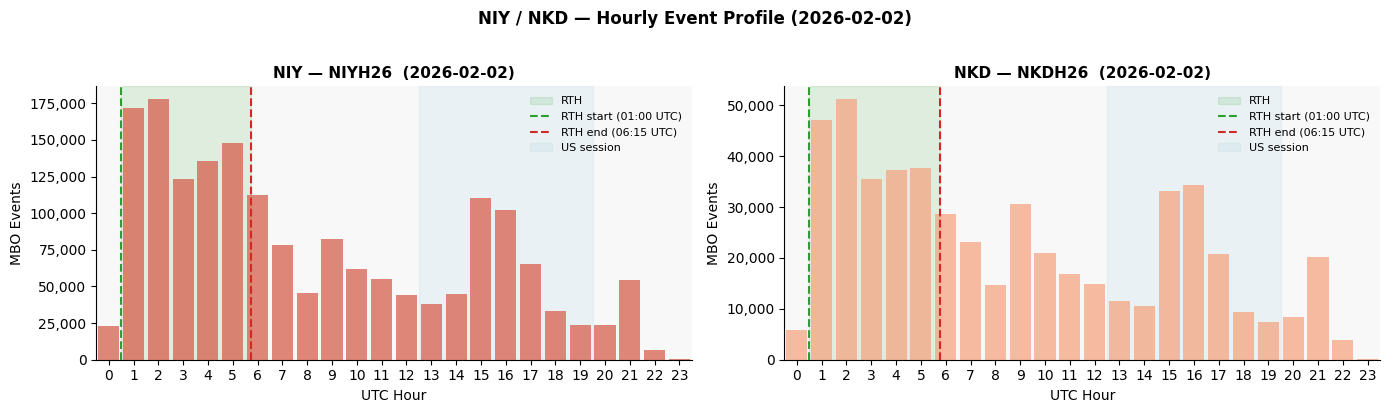

In [19]:
# NIY / NKD — 2026-02-02
# rth_utc_bounds() now supports session='asia'|'us' for multi-session products
ref_date  = "2026-02-02"
niy_nkd   = [
    ("NIY", "NIYH26", "#d6604d"),
    ("NKD", "NKDH26", "#f4a582"),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)

for ax, (product, contract, color) in zip(axes, niy_nkd):
    cfg = MARKET_CONFIG[product]
    d   = date(2026, 2, 2)
    # Default session = 'asia' (OSE Tokyo) after market_config.py update
    rth_start, rth_end = rth_utc_bounds(d, cfg, session='asia')
    rth_us_start, rth_us_end = rth_utc_bounds(d, cfg, session='us')
    print(f"{product} — asia session: {rth_start} → {rth_end} UTC")
    print(f"{product} — us session:   {rth_us_start} → {rth_us_end} UTC")

    plot_hourly_profile(
        ax, contract, ref_date, product,
        rth_start, rth_end,
        color=color,
    )

    # Overlay US session as informational shading (not the active RTH)
    us_h_start = int(rth_us_start.split(':')[0])
    us_h_end   = int(rth_us_end.split(':')[0])
    ax.axvspan(us_h_start - 0.5, us_h_end - 0.5,
               color='#9ecae1', alpha=0.15, zorder=1, label='US session')
    ax.legend(fontsize=8, frameon=False)

plt.suptitle("NIY / NKD — Hourly Event Profile (2026-02-02)", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("reports/figures/02_rth_validation/rth_NIY_NKD.png", dpi=150, bbox_inches="tight")
plt.show()


**Validation results & session decision — NIY / NKD (2026-02-02):**

**Empirical observations from the histogram:**
- **NIY asia session peak (01:00–06:00 UTC):** ~125–175K events/hour — strong primary peak
- **NIY US session peak (14:00–16:00 UTC):** ~110K events/hour — secondary peak of comparable magnitude
- **NIY inter-session trough (07:00–13:00 UTC):** ~45–80K events/hour — non-zero, representing European participants and cross-market arbitrageurs
- **NKD US session:** proportionally stronger than NIY's — NKD is the USD-denominated contract which attracts primarily US and international participants
- **Correction:** OSE activity starts at **01:00 UTC** (10:00 JST), not 02:00 UTC as originally configured. Updated in `market_config.py`.

**Market context (confirmed by practitioner sources):**  
NIY and NKD on CME Globex are used predominantly by US and international participants during the US trading session. Japanese domestic traders who want JPY-denominated Nikkei exposure use OSE products directly (Mini-Nikkei futures, NK225). The CME contracts exist primarily to allow US-based funds to trade Nikkei exposure without currency conversion infrastructure.

**Decision — two named sessions implemented in `market_config.py`:**

```python
'sessions': {
    'asia': ('01:00:00', '06:15:00'),  # OSE Tokyo — default for cross-market comparison
    'us':   ('13:30:00', '20:00:00'),  # CME US session — primary liquidity
}
```

| Session | UTC window | Liquidity | Use case |
|---------|-----------|-----------|----------|
| `asia` (default) | 01:00–06:15 UTC | Secondary on CME, primary on OSE | Cross-market comparison with HKEX, Asian microstructure analysis |
| `us` | 13:30–20:00 UTC | Primary on CME | Lead-lag vs ES, US participant order flow analysis |

**Phase 3 convention:** use `session='asia'` by default for all cross-market feature comparisons to ensure temporal alignment with HKEX products. Use `session='us'` explicitly for NIY/NKD vs ES lead-lag analysis (Phase 3, Axe 4).

> ⚠️ **Known limitation:** the US session bounds (13:30–20:00 UTC) are currently fixed and do not account for DST transitions (should be 14:30–21:00 UTC in EST). This introduces a 1-hour error during winter months (November–March). To be corrected when purchasing data around DST transition dates.


## Asia — HSI, MHI, HHI, MCH (HKEX)

**Expected profile:** HKEX products have a clean daytime session (09:15–16:30 HKT = 01:15–08:30 UTC) with a lunch break (12:00–13:00 HKT = 04:00–05:00 UTC). No overnight session — HKEX closes completely outside daytime hours (T+1 evening session 17:15–23:59 HKT exists but has negligible volume on futures).

**What to validate:**
- All activity concentrated in 01:00–09:00 UTC band
- Lunch break dip visible at hour 04:00–05:00 UTC
- Zero activity outside the daytime session
- HSI/MHI/HHI/MCH shape comparison

HSI on 2026-02-02: RTH = 01:15:00 → 08:30:00 UTC  |  Lunch: 04:00:00–05:00:00
MHI on 2026-02-02: RTH = 01:15:00 → 08:30:00 UTC  |  Lunch: 04:00:00–05:00:00
HHI on 2026-02-02: RTH = 01:15:00 → 08:30:00 UTC  |  Lunch: 04:00:00–05:00:00
MCH on 2026-02-02: RTH = 01:15:00 → 08:30:00 UTC  |  Lunch: 04:00:00–05:00:00


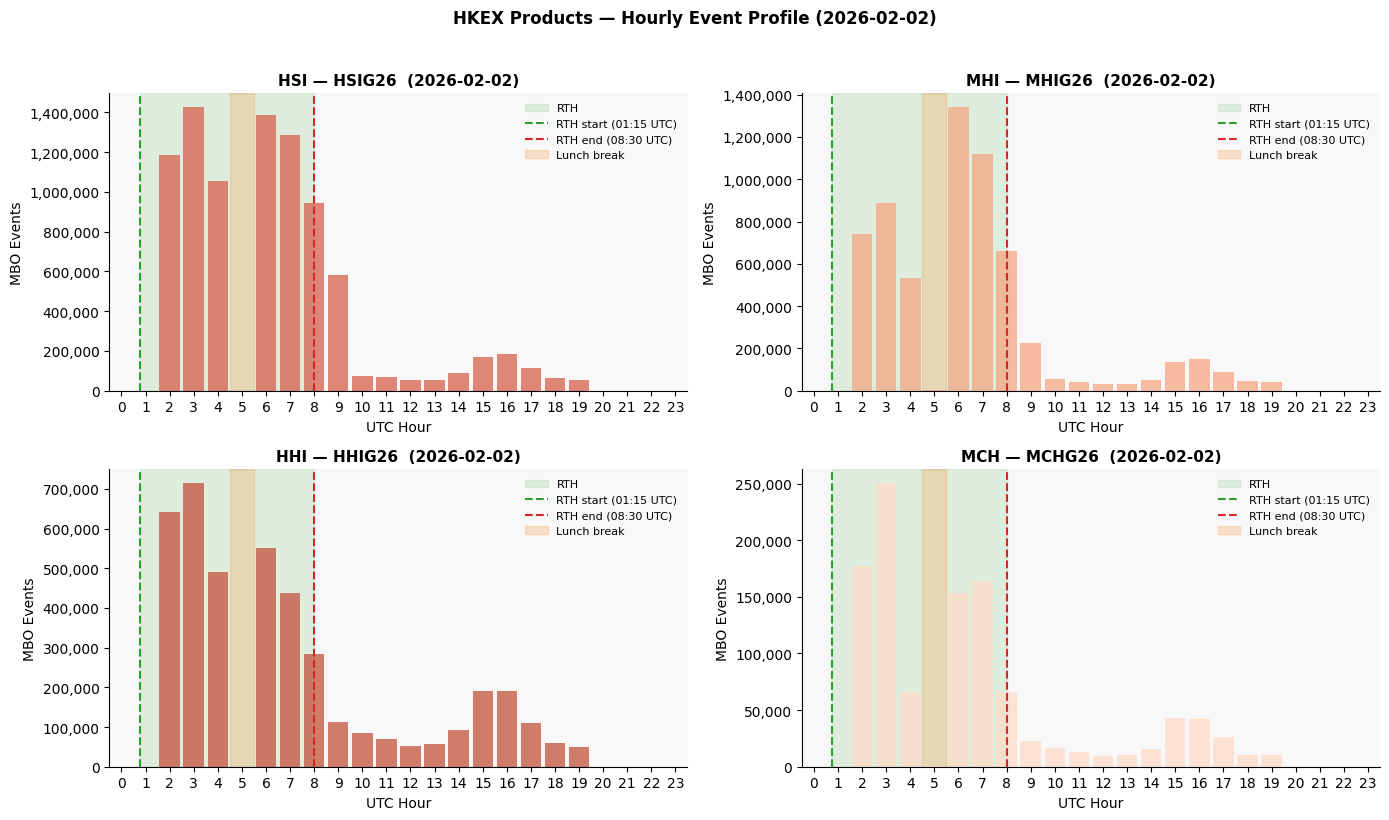

In [20]:
# HKEX — 2026-02-02
ref_date = "2026-02-02"
hkex_products = [
    ("HSI", "HSIG26", "#d6604d"),
    ("MHI", "MHIG26", "#f4a582"),
    ("HHI", "HHIG26", "#c2523c"),
    ("MCH", "MCHG26", "#fddbc7"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=False)
axes_flat = axes.flatten()

for ax, (product, contract, color) in zip(axes_flat, hkex_products):
    cfg = MARKET_CONFIG[product]
    d   = date(2026, 2, 2)
    rth_start, rth_end = rth_utc_bounds(d, cfg)
    lunch_start = cfg.get("lunch_break_start")
    lunch_end   = cfg.get("lunch_break_end")
    print(f"{product} on {ref_date}: RTH = {rth_start} → {rth_end} UTC  |  Lunch: {lunch_start}–{lunch_end}")

    plot_hourly_profile(
        ax, contract, ref_date, product,
        rth_start, rth_end,
        lunch_start=lunch_start,
        lunch_end=lunch_end,
        color=color,
    )

plt.suptitle("HKEX Products — Hourly Event Profile (2026-02-02)", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("reports/figures/02_rth_validation/rth_HKEX.png", dpi=150, bbox_inches="tight")
plt.show()


**Validation results — HSI, MHI, HHI, MCH (2026-02-02):**

- ✅ All primary activity concentrated in **01:00–09:00 UTC** band on all four products
- ✅ **Lunch break dip clearly visible** at hour 04 (04:00–05:00 UTC = 12:00–13:00 HKT) on HSI, MHI, HHI — volume drops significantly but does not reach zero (some orders are maintained through the break)
- ✅ MCH lunch break less visible due to lower absolute volume — consistent with the smaller mini H-shares contract
- ⚠️ **T+1 evening session present but minor:** HHI and MCH show non-zero activity at 09:00–18:00 UTC (17:00–02:00 HKT next day) at ~50–200K events/hour. HSI and MHI show less. This is the HKEX T+1 after-hours session — correctly excluded by our RTH definition (ends at 08:30 UTC = 16:30 HKT).
- ✅ HSI and MHI show near-identical hourly shapes — expected for same underlying index. MHI morning session (01:00–04:00 UTC) is slightly more front-loaded than HSI.
- ✅ **RTH boundaries confirmed: 01:15–08:30 UTC, lunch break 04:00–05:00 UTC excluded. No change needed.**


## Conclusions — Validated RTH Configuration

All RTH boundaries have been visually validated against empirical event distributions. The table below reflects the final configuration in `market_config.py`.

| Product | Session | RTH Start UTC | RTH End UTC | Notes |
|---------|---------|--------------|-------------|-------|
| ES      | —       | 13:30 (EDT) / 14:30 (EST) | 20:00 / 21:00 | DST-aware via `_US_DST_TRANSITIONS` |
| FDAX    | —       | 07:00 | 21:00 | Fixed, CET−1h |
| FESX    | —       | 07:00 | 21:00 | Fixed, CET−1h |
| FSMI    | —       | 07:00 | 21:00 | Fixed, CET−1h |
| NIY     | `asia`  | 01:00 | 06:15 | OSE Tokyo — default. **Corrected from 02:00 → 01:00** |
| NIY     | `us`    | 13:30 | 20:00 | CME US — primary liquidity. ⚠️ Not yet DST-aware |
| NKD     | `asia`  | 01:00 | 06:15 | Same as NIY. **Corrected from 02:00 → 01:00** |
| NKD     | `us`    | 13:30 | 20:00 | CME US — primary liquidity. ⚠️ Not yet DST-aware |
| HSI     | —       | 01:15 | 08:30 | Excl. lunch 04:00–05:00 UTC |
| MHI     | —       | 01:15 | 08:30 | Excl. lunch 04:00–05:00 UTC |
| HHI     | —       | 01:15 | 08:30 | Excl. lunch 04:00–05:00 UTC |
| MCH     | —       | 01:15 | 08:30 | Excl. lunch 04:00–05:00 UTC |

**Changes made to `market_config.py` as a result of this validation:**
1. NIY/NKD `rth_start_utc` corrected from `02:00:00` to `01:00:00` — OSE activity starts at 10:00 JST = 01:00 UTC, not 11:00 JST as originally assumed
2. NIY/NKD sessions dict added with named `asia` and `us` sessions
3. `rth_utc_bounds()` updated to support multi-session dispatch via `session` parameter
4. `session_where_clause()` updated with `session` parameter passthrough

**T+1 evening session (HKEX):** non-zero activity observed at 09:00–18:00 UTC on HHI/MCH (17:00–02:00 HKT). Correctly excluded by RTH definition. Potential future research angle: microstructure of the T+1 session vs main session.


## Next Step — `get_mbo_rth()` and `get_mbp1_rth()`

RTH boundaries are now validated and `market_config.py` is updated. The next step is to add two convenience wrappers to `dr.py` that apply the RTH filter automatically — these will be the standard API for all Phase 3 feature engineering.

```python
# Target API — single session products
tbl = dr.get_mbo_rth('ESZ25',   '2025-10-10')          # MBO, RTH only
tbl = dr.get_mbp1_rth('ESZ25',  '2025-10-10')          # MBP-1, RTH only
tbl = dr.get_mbp1_rth('HSIG26', '2026-02-02')          # HKEX, lunch break excluded

# Target API — multi-session products (NIY, NKD)
tbl = dr.get_mbo_rth('NIYH26', '2026-02-02')                      # asia session (default)
tbl = dr.get_mbo_rth('NIYH26', '2026-02-02', session='us')        # US session
```

**Implementation plan for `dr.py`:**
- `get_mbo_rth(contract, date_str, columns=None, session='default')` → `get_mbo()` + `filter_rth(session=session)`
- `get_mbp1_rth(contract, date_str, columns=None, session='default')` → `get_mbp1()` + `filter_rth(session=session)`
- `filter_rth()` passes `session` to `session_where_clause(use_rth=True, session=session)`
- All RTH logic (DST, CET conversion, lunch break, multi-session) already handled in `market_config.py` — no duplication needed in `dr.py`
